# AdaBoost Ensemble: Complete Educational Example

AdaBoost (Adaptive Boosting) is an ensemble learning method that combines multiple weak learners to create a strong classifier.

## Key Concepts:
- **Weak Learners**: Decision stumps or shallow trees
- **Iterative Process**: Each iteration focuses on misclassified samples
- **Sample Weights**: Increases weights on hard-to-classify instances
- **Final Prediction**: Weighted majority vote of all base learners

## Understanding AdaBoost Algorithm

AdaBoost works as follows:

1. **Initialize Weights**: All samples start with equal weight (1/n)
2. **Train Weak Learner**: Fit a weak learner (decision stump) on weighted data
3. **Calculate Error**: Compute weighted error rate
4. **Calculate Alpha**: Determine the importance of this learner (based on accuracy)
5. **Update Weights**: Increase weights for misclassified samples
6. **Repeat**: Train next weak learner on updated weights
7. **Final Prediction**: Combine predictions using weighted majority vote

The key insight: **Hard examples get more attention!**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, 
                             classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("="*70)
print("AdaBoost ENSEMBLE: BREAST CANCER CLASSIFICATION")
print("="*70)

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print(f"\nDataset: Breast Cancer")
print(f"Shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Classes: {np.unique(y)}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Target names: {cancer.target_names}")

AdaBoost ENSEMBLE: BREAST CANCER CLASSIFICATION

Dataset: Breast Cancer
Shape: (569, 30)
Features: 30
Classes: [0 1]
Class distribution: [212 357]
Target names: ['malignant' 'benign']


In [3]:
# Data preprocessing
print("\n1. DATA PREPROCESSING")
print("-" * 70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Malignant rate (train): {(1 - y_train.mean()):.2%}")
print(f"Benign rate (train): {y_train.mean():.2%}")


1. DATA PREPROCESSING
----------------------------------------------------------------------
Training samples: 455
Testing samples: 114
Malignant rate (train): 37.36%
Benign rate (train): 62.64%


## Step 1: Single Decision Stump (weak learner)

In [4]:
print("\n2. BASELINE: SINGLE DECISION STUMP")
print("-" * 70)

stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)

stump_train_pred = stump.predict(X_train)
stump_test_pred = stump.predict(X_test)

stump_train_acc = accuracy_score(y_train, stump_train_pred)
stump_test_acc = accuracy_score(y_test, stump_test_pred)

print(f"Decision Stump Training Accuracy: {stump_train_acc:.4f}")
print(f"Decision Stump Testing Accuracy:  {stump_test_acc:.4f}")


2. BASELINE: SINGLE DECISION STUMP
----------------------------------------------------------------------
Decision Stump Training Accuracy: 0.9231
Decision Stump Testing Accuracy:  0.9211


## Step 2: AdaBoost with Different Numbers of Estimators

In [5]:
print("\n3. AdaBoost WITH DIFFERENT CONFIGURATIONS")
print("-" * 70)

n_estimators_list = [1, 5, 10, 20, 50, 100]
results = []

for n_est in n_estimators_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_est,
        learning_rate=1.0,
        random_state=42
    )
    
    ada.fit(X_train, y_train)
    
    train_pred = ada.predict(X_train)
    test_pred = ada.predict(X_test)
    
    train_proba = ada.predict_proba(X_train)[:, 1]
    test_proba = ada.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    
    results.append({
        'n_estimators': n_est,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_auc': train_auc,
        'test_auc': test_auc
    })
    
    print(f"n_estimators = {n_est:4}    |    Train Accuracy: {train_acc:.4f}    |    Test Accuracy: {test_acc:.4f}    |    Train AUC:    {train_auc:.4f}    |    Test AUC:    {test_auc:.4f}")


3. AdaBoost WITH DIFFERENT CONFIGURATIONS
----------------------------------------------------------------------
n_estimators =    1    |    Train Accuracy: 0.9231    |    Test Accuracy: 0.9211    |    Train AUC:    0.9066    |    Test AUC:    0.9077
n_estimators =    5    |    Train Accuracy: 0.9648    |    Test Accuracy: 0.9298    |    Train AUC:    0.9957    |    Test AUC:    0.9684
n_estimators =   10    |    Train Accuracy: 0.9824    |    Test Accuracy: 0.9649    |    Train AUC:    0.9990    |    Test AUC:    0.9858
n_estimators =   20    |    Train Accuracy: 0.9956    |    Test Accuracy: 0.9561    |    Train AUC:    1.0000    |    Test AUC:    0.9841
n_estimators =   50    |    Train Accuracy: 1.0000    |    Test Accuracy: 0.9561    |    Train AUC:    1.0000    |    Test AUC:    0.9825
n_estimators =  100    |    Train Accuracy: 1.0000    |    Test Accuracy: 0.9561    |    Train AUC:    1.0000    |    Test AUC:    0.9818


## Step 3: Detailed Analysis with Optimal AdaBoost

In [6]:
print("\n4. DETAILED ANALYSIS (n_estimators=50)")
print("-" * 70)

ada_optimal = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_optimal.fit(X_train, y_train)

# Predictions
y_train_pred = ada_optimal.predict(X_train)
y_test_pred = ada_optimal.predict(X_test)
y_train_proba = ada_optimal.predict_proba(X_train)[:, 1]
y_test_proba = ada_optimal.predict_proba(X_test)[:, 1]

# Metrics
print("\nTraining Set Metrics:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")

print("\nTesting Set Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=cancer.target_names))


4. DETAILED ANALYSIS (n_estimators=50)
----------------------------------------------------------------------

Training Set Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Testing Set Metrics:
  Accuracy:  0.9561
  Precision: 0.9467
  Recall:    0.9861
  F1-Score:  0.9660
  ROC-AUC:   0.9825

Classification Report (Test Set):
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



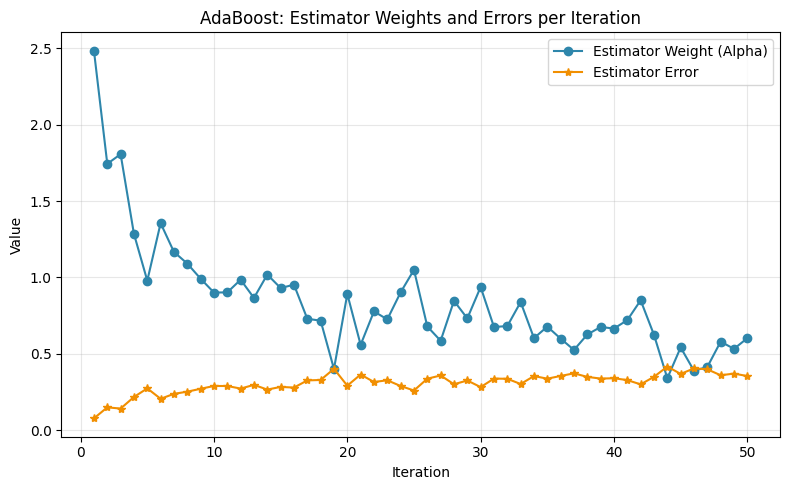

In [7]:
# Plot AdaBoost estimator weights (alpha) and errors per iteration
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ada_optimal.estimator_weights_) + 1), ada_optimal.estimator_weights_, marker='o', label='Estimator Weight (Alpha)', color='#2E86AB')
plt.plot(range(1, len(ada_optimal.estimator_errors_) + 1), ada_optimal.estimator_errors_, marker='*', label='Estimator Error', color='#F18F01')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('AdaBoost: Estimator Weights and Errors per Iteration')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

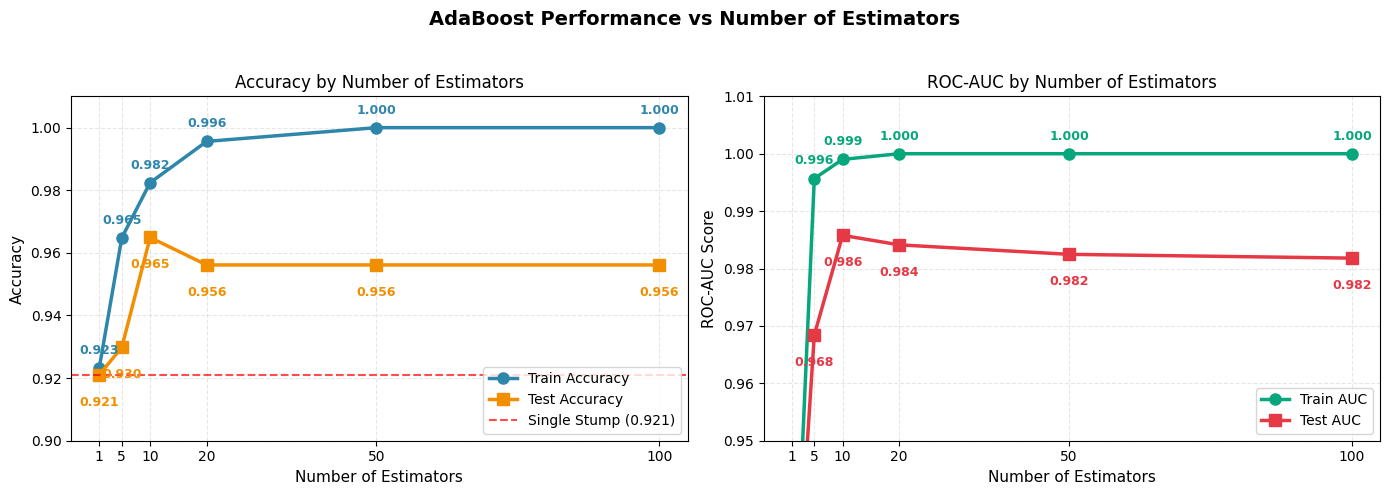

In [8]:
results_df = pd.DataFrame(results)

# Create visualization with marked points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AdaBoost Performance vs Number of Estimators', fontsize=14, fontweight='bold')

# Plot 1: Accuracy
ax = axes[0]
ax.plot(n_estimators_list, [r['train_acc'] for r in results], 'o-', 
        label='Train Accuracy', linewidth=2.5, markersize=8, color='#2E86AB')
ax.plot(n_estimators_list, [r['test_acc'] for r in results], 's-', 
        label='Test Accuracy', linewidth=2.5, markersize=8, color='#F18F01')

# Mark points with values
for n_est, train_acc, test_acc in zip(n_estimators_list, 
                                       [r['train_acc'] for r in results],
                                       [r['test_acc'] for r in results]):
    ax.annotate(f"{train_acc:.3f}", (n_est, train_acc), xytext=(0,8), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, color='#2E86AB', fontweight='bold')
    ax.annotate(f"{test_acc:.3f}", (n_est, test_acc), xytext=(0,-15), textcoords='offset points',
                ha='center', va='top', fontsize=9, color='#F18F01', fontweight='bold')

ax.axhline(y=stump_test_acc, color='red', linestyle='--', linewidth=1.5, 
           label=f'Single Stump ({stump_test_acc:.3f})', alpha=0.7)
ax.set_xlabel('Number of Estimators', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy by Number of Estimators', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(n_estimators_list)
ax.set_ylim([0.90, 1.01])

# Plot 2: AUC
ax = axes[1]
ax.plot(n_estimators_list, [r['train_auc'] for r in results], 'o-', 
        label='Train AUC', linewidth=2.5, markersize=8, color='#06A77D')
ax.plot(n_estimators_list, [r['test_auc'] for r in results], 's-', 
        label='Test AUC', linewidth=2.5, markersize=8, color='#E63946')

# Mark points with values
for n_est, train_auc, test_auc in zip(n_estimators_list, 
                                       [r['train_auc'] for r in results],
                                       [r['test_auc'] for r in results]):
    ax.annotate(f"{train_auc:.3f}", (n_est, train_auc), xytext=(0,8), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, color='#06A77D', fontweight='bold')
    ax.annotate(f"{test_auc:.3f}", (n_est, test_auc), xytext=(0,-15), textcoords='offset points',
                ha='center', va='top', fontsize=9, color='#E63946', fontweight='bold')

ax.set_xlabel('Number of Estimators', fontsize=11)
ax.set_ylabel('ROC-AUC Score', fontsize=11)
ax.set_title('ROC-AUC by Number of Estimators', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(n_estimators_list)
ax.set_ylim([0.95, 1.01])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('adaboost_performance_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Feature Importance

In [9]:
print("\n5. FEATURE IMPORTANCE IN AdaBoost")
print("-" * 70)

feature_importance = ada_optimal.feature_importances_
feature_names = cancer.feature_names

# Get top 10 features
top_indices = np.argsort(feature_importance)[-10:][::-1]
top_features = feature_names[top_indices]
top_importance = feature_importance[top_indices]

print("\nTop 10 Most Important Features:")
for i, (feature, importance) in enumerate(zip(top_features, top_importance), 1):
    print(f"  {i:2d}. {feature:30s} {importance:.4f}")


5. FEATURE IMPORTANCE IN AdaBoost
----------------------------------------------------------------------

Top 10 Most Important Features:
   1. worst texture                  0.1249
   2. worst concave points           0.1214
   3. area error                     0.1016
   4. worst radius                   0.0941
   5. mean compactness               0.0629
   6. mean smoothness                0.0579
   7. worst area                     0.0531
   8. worst smoothness               0.0518
   9. worst symmetry                 0.0514
  10. mean texture                   0.0457


## Step 6: Comparison with other methods

In [10]:

print("\n7. COMPARISON WITH OTHER ENSEMBLE METHODS")
print("-" * 70)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier

models = {
    'Decision Stump': DecisionTreeClassifier(max_depth=1, random_state=42),
    'AdaBoost (10)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=10,
        random_state=42
    ),
    'AdaBoost (50)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Bagging': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=50,
        random_state=42
    )
}

comparison_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    test_auc = roc_auc_score(y_test, test_proba)
    
    comparison_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Test AUC': test_auc
    })
    
    print(f"\n{name:25s}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Test AUC:       {test_auc:.4f}")

comparison_df = pd.DataFrame(comparison_results)


7. COMPARISON WITH OTHER ENSEMBLE METHODS
----------------------------------------------------------------------

Decision Stump           
  Train Accuracy: 0.9231
  Test Accuracy:  0.9211
  Test AUC:       0.9077

AdaBoost (10)            
  Train Accuracy: 0.9824
  Test Accuracy:  0.9649
  Test AUC:       0.9858

AdaBoost (50)            
  Train Accuracy: 1.0000
  Test Accuracy:  0.9561
  Test AUC:       0.9825

Random Forest            
  Train Accuracy: 1.0000
  Test Accuracy:  0.9561
  Test AUC:       0.9917

Gradient Boosting        
  Train Accuracy: 1.0000
  Test Accuracy:  0.9474
  Test AUC:       0.9884

Bagging                  
  Train Accuracy: 0.9956
  Test Accuracy:  0.9386
  Test AUC:       0.9914


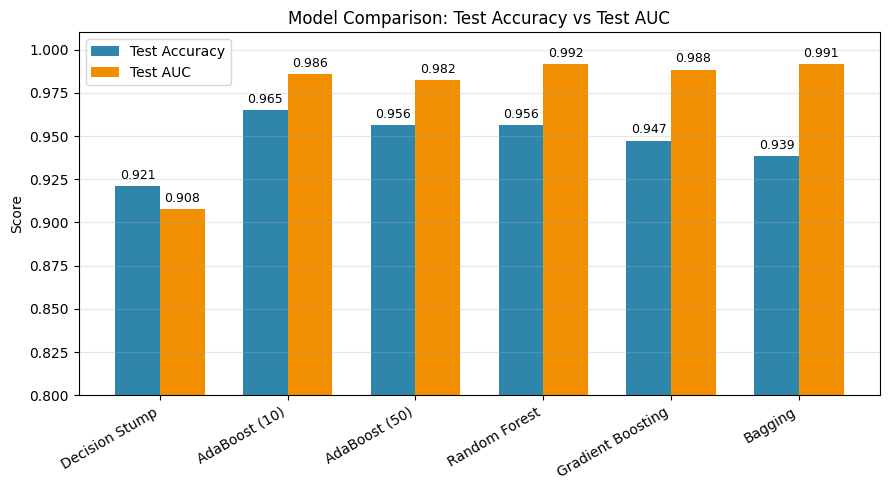

In [11]:
# Visualize model comparison: Test Accuracy and Test AUC
fig, ax1 = plt.subplots(1, 1, figsize=(9, 5))
bar_width = 0.35
x = np.arange(len(comparison_df))

bars1 = ax1.bar(x - bar_width/2, comparison_df['Test Accuracy'], bar_width, label='Test Accuracy', color='#2E86AB')
bars2 = ax1.bar(x + bar_width/2, comparison_df['Test AUC'], bar_width, label='Test AUC', color='#F18F01')

ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'], rotation=30, ha='right')
ax1.set_ylim(0.8, 1.01)
ax1.set_ylabel('Score')
ax1.set_title('Model Comparison: Test Accuracy vs Test AUC')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Annotate bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()